In [1]:
%load_ext autoreload
%autoreload 2
from __future__ import annotations
import numpy as np
import pandas as pd

import random
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, roc_auc_score

import cripser
from pathlib import Path
import matplotlib.pyplot as plt
import importlib
from xlstm import xLSTMBlockStack, xLSTMBlockStackConfig, mLSTMBlockConfig, mLSTMLayerConfig

from memory_profiler import memory_usage
from time import perf_counter

from topo.utils import DataGenerator1D, DataGenerator2D, MemoryUtils

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available() else "cpu")


In [ ]:
"💾 memory cleanup"
MemoryUtils.clear_jupyter_state()

MemoryUtils.clear_runtime_memory()

MemoryUtils.clear_compilation_cache()


In [2]:
"COMMAND CENTER"
# "sequence" = CNN/LSTM + image TDA datasets
# "celltracking" = CTC/celltracking clip runner
# "glas" = GlaS classifier
# "xlstm" = xLSTM sequence ablation, after running the sequence loader
SCENARIO = "sequence"
DATASET  = "moving_mnist"  # moving_mnist, davis_images, celltracking_fluo, bouncing_balls, glioblastoma, hela

# Run scope. Set to None to use topo/config.py defaults.
RUN_SEEDS_OVERRIDE           = list(range(2)) # None # e.g. list(range(8))
PREDICT_STEPS_AHEAD_OVERRIDE = None # e.g. 10

# Shared model/data overrides.
LATENT_DIM_OVERRIDE = None
HIDDEN_DIM_OVERRIDE = None
EPOCHS_OVERRIDE     = None
LEARNING_RATE_OVERRIDE   = None
BETTI_SCALE_OVERRIDE     = None
N_STEPS_OVERRIDE         = None
NUM_TRAIN_CLIPS_OVERRIDE = None  # bouncing_balls only
NUM_TEST_CLIPS_OVERRIDE  = None   # bouncing_balls only
FORCE_REBUILD_DATA_CACHE = False
AE_FRAME_BATCH_SIZE_OVERRIDE     = None
AE_MAX_FRAMES_PER_EPOCH_OVERRIDE = None

# Regular sequence runner.
LEGACY_TDA_MODES_OVERRIDE = ["none", "h0"] #"h1_shuffle"#["none", "h0", "h0_zero", "h1", "h1_zero", "h0_shuffle", "h0_noise", "h0_shift"]
RETRAIN_ENCODER           = False
RETRAIN_PREDICTOR         = True
RUN_LATENT_TDA_IN_MAIN    = False
LATENT_TDA_MODES_OVERRIDE = ["z", "z_latent_h0", "z_latent_h1", "z_latent_both"]
RETRAIN_LATENT_TDA_PREDICTOR_OVERRIDE  = None
RECOMPUTE_LATENT_TDA_FEATURES_OVERRIDE = None

# Celltracking / CTC runner.
CELLTRACKING_DATASET = DATASET
FORCE_REBUILD_CELLTRACKING_TENSORS         = False
RECOMPUTE_CELLTRACKING_LATENT_TDA_FEATURES = False
RUN_CELLTRACKING_LATENT_TDA_OVERRIDE = False
CELLTRACKING_INPUT_VARIANTS_OVERRIDE = {
    "no_tda": "z",
    "h0": "z_h0",
    "h0_shuffle": "z_h0_shuffle",
    "h0_noise": "z_h0_noise",
    "h0_shift": "z_h0_shift",}
CELLTRACKING_TASKS_OVERRIDE     = ["next"]
MAX_TRAIN_CLIPS_OVERRIDE        = None
MAX_TEST_CLIPS_OVERRIDE         = None
CELLTRACKING_AE_EPOCHS_OVERRIDE = None
CELLTRACKING_AE_MAX_FRAMES_PER_EPOCH_OVERRIDE = None
CELLTRACKING_MLP_EPOCHS_OVERRIDE     = None
CELLTRACKING_MLP_BATCH_SIZE_OVERRIDE = None

# GlaS classifier.
GLAS_TDA_MODES = ["none", "h1", "both"]
GLAS_SEEDS     = [0, 1, 2, 3, 4]
GLAS_EPOCHS    = 20

# xLSTM runner.
XLSTM_MODES_OVERRIDE        = ["none", "h0", "h0_zero", "h0_shuffle", "h0_noise", "h0_shift"]
XLSTM_RUN_SEEDS_OVERRIDE    = None
XLSTM_CONTEXT_LEN_OVERRIDE  = None
XLSTM_HIDDEN_DIM_OVERRIDE   = None
XLSTM_LAYERS_OVERRIDE       = None
XLSTM_DROPOUT_OVERRIDE      = None
XLSTM_EPOCHS_OVERRIDE       = None
XLSTM_LR_OVERRIDE           = None
XLSTM_WEIGHT_DECAY_OVERRIDE = None
XLSTM_BATCH_SIZE_OVERRIDE   = None
XLSTM_STANDARDIZE_INPUTS_OVERRIDE = None
XLSTM_STANDARDIZE_TARGETS_OVERRIDE = None
XLSTM_MAX_TRAIN_WINDOWS_OVERRIDE= None
XLSTM_MAX_TEST_WINDOWS_OVERRIDE = None
XLSTM_RETRAIN_ENCODER           = False
XLSTM_RUN_LATENT_TDA_OVERRIDE   = False
XLSTM_LATENT_TDA_MODES_OVERRIDE = ["z", "z_latent_h0", "z_latent_h1", "z_latent_both"]
XLSTM_RECOMPUTE_LATENT_TDA_FEATURES_OVERRIDE = False

def cc(name, default=None):
    """Return command-center override unless it is None."""
    value = globals().get(name, None)
    return default if value is None else value

print(f"Command center: scenario={SCENARIO}, dataset={DATASET}, horizon_override={PREDICT_STEPS_AHEAD_OVERRIDE}")


Command center: scenario=sequence, dataset=moving_mnist, horizon_override=None


Dataset: moving_mnist | X_train: torch.Size([20, 2000, 1, 64, 64]) | X_test: torch.Size([20, 300, 1, 64, 64])
Input ranges: train min=0.0000 max=1.0000             mean=0.0494 | test min=0.0000             max=1.0000 mean=0.0502
Runner config: seeds=[0, 1], predict_steps_ahead=5, modes=['none', 'h0']
Using sequence compute device: cuda

================ legacy seed=0 ================

-------- DATASET=moving_mnist seed=0 TDA_MODE=none --------
Loading shared encoder: models/moving_mnist/encoders/encoder_seed0_T20_B2000_H64_W64_latent64.pt
Predictor retraining: models/moving_mnist/model_seed0_pred5_tda_none.pt

--- Phase 2: Training LSTM Predictor (USE_TDA=False) ---
Predictor device: cuda

--- Epoch 01/10 ---
Epoch 01/10 | Training MSE Loss: 29.3605

--- Epoch 02/10 ---
Epoch 02/10 | Training MSE Loss: 29.1744

--- Epoch 03/10 ---
Epoch 03/10 | Training MSE Loss: 28.9924

--- Epoch 04/10 ---
Epoch 04/10 | Training MSE Loss: 28.8243

--- Epoch 05/10 ---
Epoch 05/10 | Training MSE Loss: 

test_mse              warmup_excluded_mse             
           mean       std  n                mean       std  n
mode                                                         
h0    23.784198  4.068000  2           23.752706  4.059457  2
none  23.819946  4.235285  2           23.791129  4.233071  2

,dataset,seed,mode,test_mse,warmup_excluded_mse
1,moving_mnist,0,h0,27.852198,27.812162
0,moving_mnist,0,none,28.055231,28.024200
3,moving_mnist,1,h0,19.716198,19.693249
2,moving_mnist,1,none,19.584661,19.558058


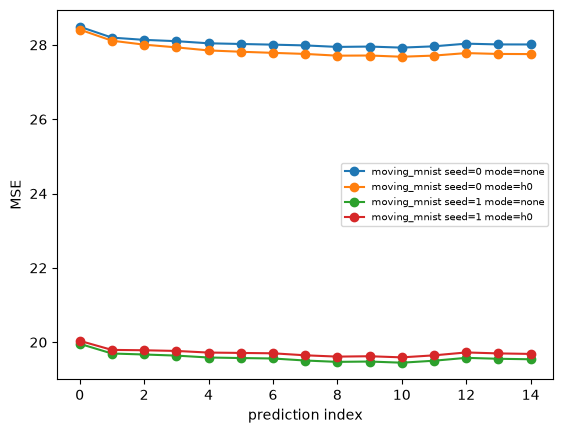

In [3]:
"ML pipeline + TDA - for SEQUENCES"
"""experiment orchestration. Reusable CNN/TDA classes and helpers are in topo.ml_tda."""
import topo.config as topo_config
import topo.ml_tda as ml_tda
import topo.ml_tda_latent as latent_tda
importlib.reload(topo_config)
importlib.reload(ml_tda)
importlib.reload(latent_tda)
DATASET_CONFIGS = topo_config.DATASET_CONFIGS

from topo.ml_tda import (
    SpatialEncoder,
    SpatialDecoder,
    TopologicalPredictor,
    load_or_train_model,
    load_video_dataset,
    parse_tda_control_mode,
    test_predictor,)

if SCENARIO not in {"sequence", "xlstm"}:
    print(f"Skipping sequence data loader because SCENARIO={SCENARIO!r}")
elif DATASET_CONFIGS[DATASET].get("kind") != "ctc_tif_clips" and DATASET not in ["celltracking_davis", "celltracking_fluo"]:
    run_config = dict(DATASET_CONFIGS[DATASET])
    if DATASET == "bouncing_balls":
        if NUM_TRAIN_CLIPS_OVERRIDE is not None:
            run_config["num_train_clips"] = NUM_TRAIN_CLIPS_OVERRIDE
        if NUM_TEST_CLIPS_OVERRIDE is not None:
            run_config["num_test_clips"] = NUM_TEST_CLIPS_OVERRIDE
        run_config["force_rebuild_cache"] = FORCE_REBUILD_DATA_CACHE

    RUN_SEEDS         = cc("RUN_SEEDS_OVERRIDE", run_config.get("RUN_SEEDS", list(range(5))))
    LEGACY_TDA_MODES  = cc("LEGACY_TDA_MODES_OVERRIDE", run_config.get("LEGACY_TDA_MODES", ["none", "h0", "h1", "both"]))
    RETRAIN_ENCODER   = cc("RETRAIN_ENCODER", False)
    RETRAIN_PREDICTOR = cc("RETRAIN_PREDICTOR", True)
    RUN_LATENT_TDA_IN_MAIN = cc("RUN_LATENT_TDA_IN_MAIN", False)

    train_array, test_array = load_video_dataset(run_config)
    X_train = torch.from_numpy(train_array).unsqueeze(2)
    X_test  = torch.from_numpy(test_array).unsqueeze(2)
    if X_train.dtype != torch.uint8:
        X_train = X_train.float()
        X_test  = X_test.float()
    vid_len, batch_size, _, h_image, w_image = X_train.shape

    X_train_stats = X_train.float() / 255.0 if X_train.dtype == torch.uint8 else X_train.float()
    X_test_stats  = X_test.float() / 255.0 if X_test.dtype == torch.uint8 else X_test.float()
    print(f"Dataset: {DATASET} | X_train: {X_train.shape} | X_test: {X_test.shape}")
    print(f"Input ranges: train min={X_train_stats.min().item():.4f} max={X_train_stats.max().item():.4f} \
            mean={X_train_stats.mean().item():.4f} | "f"test min={X_test_stats.min().item():.4f} \
            max={X_test_stats.max().item():.4f} mean={X_test_stats.mean().item():.4f}")

    LATENT_DIM = cc("LATENT_DIM_OVERRIDE", run_config.get("LATENT_DIM", 128))
    HIDDEN_DIM = cc("HIDDEN_DIM_OVERRIDE", run_config.get("HIDDEN_DIM", 128))
    EPOCHS     = cc("EPOCHS_OVERRIDE", run_config.get("EPOCHS", 10))
    LEARNING_RATE = cc("LEARNING_RATE_OVERRIDE", run_config.get("learning_rate", 3e-4))
    BETTI_SCALE   = cc("BETTI_SCALE_OVERRIDE", run_config.get("BETTI_SCALE", 15))
    N_STEPS       = cc("N_STEPS_OVERRIDE", run_config.get("N_STEPS", 15)) # Betti curve length
    PREDICT_STEPS_AHEAD = cc("PREDICT_STEPS_AHEAD_OVERRIDE", run_config.get("PREDICT_STEPS_AHEAD", 1))
    AE_FRAME_BATCH_SIZE = cc("AE_FRAME_BATCH_SIZE_OVERRIDE", run_config.get("AE_FRAME_BATCH_SIZE", 256))
    AE_MAX_FRAMES_PER_EPOCH = cc("AE_MAX_FRAMES_PER_EPOCH_OVERRIDE", run_config.get("AE_MAX_FRAMES_PER_EPOCH", 8192))
    ml_tda.configure_runtime(
        DATASET=DATASET,
        LATENT_DIM=LATENT_DIM,
        BETTI_SCALE=BETTI_SCALE,
        N_STEPS=N_STEPS,
        PREDICT_STEPS_AHEAD=PREDICT_STEPS_AHEAD,
        EPOCHS=EPOCHS,
        DEVICE=device,
        AE_FRAME_BATCH_SIZE=AE_FRAME_BATCH_SIZE,
        AE_MAX_FRAMES_PER_EPOCH=AE_MAX_FRAMES_PER_EPOCH,)
    print(f"Runner config: seeds={RUN_SEEDS}, predict_steps_ahead={PREDICT_STEPS_AHEAD}, modes={LEGACY_TDA_MODES}")
    print(f"Using sequence compute device: {ml_tda.get_runtime_device()}")

    if SCENARIO == "xlstm":
        print("Loaded sequence tensors/config for xLSTM; skipping regular sequence training.")
    else:
        legacy_results = []
        legacy_runs    = {}

        for EXPERIMENT_SEED in RUN_SEEDS:
            print(f"\n================ legacy seed={EXPERIMENT_SEED} ================")
            random.seed(EXPERIMENT_SEED)
            np.random.seed(EXPERIMENT_SEED)
            torch.manual_seed(EXPERIMENT_SEED)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(EXPERIMENT_SEED)

            for TDA_MODE in LEGACY_TDA_MODES:
                ml_tda.configure_runtime(EXPERIMENT_SEED=EXPERIMENT_SEED, TDA_MODE=TDA_MODE)
                BASE_TDA_MODE, _ = parse_tda_control_mode(TDA_MODE)
                USE_TDA          = BASE_TDA_MODE != "none"
                if BASE_TDA_MODE == "none":
                    TDA_DIM = 0
                elif BASE_TDA_MODE in {"h0", "h1"}:
                    TDA_DIM = N_STEPS
                else:
                    TDA_DIM = 2 * N_STEPS
                INPUT_DIM = LATENT_DIM + TDA_DIM

                print(f"\n-------- DATASET={DATASET} seed={EXPERIMENT_SEED} TDA_MODE={TDA_MODE} --------")
                encoder  = SpatialEncoder(latent_dim=LATENT_DIM)
                decoder  = SpatialDecoder(latent_dim=LATENT_DIM, output_size=(h_image, w_image))
                model    = TopologicalPredictor(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM)
                load_or_train_model(encoder, decoder, model, X_train, RETRAIN_ENCODER, RETRAIN_PREDICTOR, USE_TDA, LEARNING_RATE)
                test_mse, per_frame_mse = test_predictor(model, encoder, X_test, USE_TDA)
                row = {
                    "dataset": DATASET,
                    "seed": EXPERIMENT_SEED,
                    "mode": TDA_MODE,
                    "test_mse": float(test_mse),
                    "warmup_excluded_mse": float(per_frame_mse[1:].mean()) if len(per_frame_mse) > 1 else float(test_mse),}
                legacy_results.append(row)
                legacy_runs[(EXPERIMENT_SEED, TDA_MODE)] = {"test_mse": test_mse, "per_frame_mse": per_frame_mse}
                print("legacy run summary:", row)

        legacy_results_df = pd.DataFrame(legacy_results)
        legacy_summary_df = ml_tda.summarize_metric_runs(
            legacy_results_df,
            group_cols="mode",
            metric_cols=["test_mse", "warmup_excluded_mse"],
            sort_metric="test_mse",)

        legacy_paired_df = legacy_results_df.pivot(index="seed", columns="mode", values="test_mse")
        if {"none", "h1"}.issubset(legacy_paired_df.columns):
            legacy_paired_df["h1_minus_none"] = legacy_paired_df["h1"] - legacy_paired_df["none"]
            print("\nPaired h1 - none differences; negative means h1 is better:")
            print(legacy_paired_df)
        print("\nLegacy per-run results:")
        print(legacy_results_df.to_string(index=False))
        print("\nLegacy mean +/- std by mode:")
        print(legacy_summary_df)
        display(legacy_summary_df)
        display(legacy_results_df.sort_values(["seed", "mode"]))

        if RUN_LATENT_TDA_IN_MAIN:
            LATENT_TDA_RUN_SEEDS = cc("RUN_SEEDS_OVERRIDE", run_config.get("RUN_SEEDS", list(range(5))))
            LATENT_TDA_MODES     = cc("LATENT_TDA_MODES_OVERRIDE", ["z", "z_latent_h0", "z_latent_h1", "z_latent_both"])
            LATENT_TDA_WINDOW    = run_config.get("LATENT_TDA_WINDOW", 20)
            LATENT_TDA_BINS      = run_config.get("LATENT_TDA_BINS", 16)
            LATENT_TDA_EPOCHS    = run_config.get("LATENT_TDA_EPOCHS", 10)
            LATENT_TDA_LR        = LEARNING_RATE
            LATENT_TDA_MAX_TRAIN = run_config.get("LATENT_TDA_MAX_TRAIN")
            LATENT_TDA_MAX_TEST  = run_config.get("LATENT_TDA_MAX_TEST")
            RETRAIN_LATENT_TDA_PREDICTOR  = cc("RETRAIN_LATENT_TDA_PREDICTOR_OVERRIDE", run_config.get("RETRAIN_LATENT_TDA_PREDICTOR", True))
            RECOMPUTE_LATENT_TDA_FEATURES = cc("RECOMPUTE_LATENT_TDA_FEATURES_OVERRIDE", run_config.get("RECOMPUTE_LATENT_TDA_FEATURES", True))

            latent_tda.configure_runtime(
                DATASET=DATASET,
                LATENT_DIM=LATENT_DIM,
                HIDDEN_DIM=HIDDEN_DIM,
                PREDICT_STEPS_AHEAD=PREDICT_STEPS_AHEAD,
                RETRAIN_ENCODER=False,
                LATENT_TDA_WINDOW=LATENT_TDA_WINDOW,
                LATENT_TDA_BINS=LATENT_TDA_BINS,
                LATENT_TDA_EPOCHS=LATENT_TDA_EPOCHS,
                LATENT_TDA_LR=LATENT_TDA_LR,
                RETRAIN_LATENT_TDA_PREDICTOR=RETRAIN_LATENT_TDA_PREDICTOR,
                RECOMPUTE_LATENT_TDA_FEATURES=RECOMPUTE_LATENT_TDA_FEATURES,)
            print(
                f"\nRunning TDA-on-latents: modes={LATENT_TDA_MODES}, "
                f"window={LATENT_TDA_WINDOW}, bins={LATENT_TDA_BINS}, "
                f"predict_steps_ahead={PREDICT_STEPS_AHEAD}")
            latent_tda_results_df, latent_tda_summary_df, latent_tda_paired_df = latent_tda.run_latent_tda_trajectory_experiment(
                X_train=X_train,
                X_test=X_test,
                run_seeds=LATENT_TDA_RUN_SEEDS,
                modes=LATENT_TDA_MODES,
                max_train=LATENT_TDA_MAX_TRAIN,
                max_test=LATENT_TDA_MAX_TEST,
                display_fn=display,)


In [ ]:
"celltracking data loader + runner"
# Cache-first celltracking preprocessing + ablation runner.
# Reusable celltracking helpers live in topo.ml_tda_celltracking.

import topo.config as topo_config
import topo.ml_tda_celltracking as ct_tda
importlib.reload(topo_config)
importlib.reload(ct_tda)
DATASET_CONFIGS = topo_config.DATASET_CONFIGS

from topo.ml_tda_celltracking import (
    compute_tda_features,
    encode_clips,
    features_for_latent_tda_mode,
    load_or_build_celltracking_tensors,
    load_or_compute_latent_tda_features,
    load_or_train_shared_encoder,
    make_latent_tda_supervised,
    make_supervised,
    prepare_clip_tensor_for_sequence_pipeline,
    set_all_seeds,
    tensor_range_text,
    train_mlp_variant,
)

if SCENARIO != "celltracking":
    print(f"Skipping celltracking runner because SCENARIO={SCENARIO!r}")
else:
    CELLTRACKING_DATASET = cc("CELLTRACKING_DATASET", DATASET)
    FORCE_REBUILD_CELLTRACKING_TENSORS = cc("FORCE_REBUILD_CELLTRACKING_TENSORS", False)
    RECOMPUTE_CELLTRACKING_LATENT_TDA_FEATURES = cc("RECOMPUTE_CELLTRACKING_LATENT_TDA_FEATURES", False)
    celltracking_cfg = DATASET_CONFIGS[CELLTRACKING_DATASET]
    RUN_CELLTRACKING_LATENT_TDA = cc("RUN_CELLTRACKING_LATENT_TDA_OVERRIDE", celltracking_cfg.get("RUN_CELLTRACKING_LATENT_TDA", True))
    CELLTRACKING_MODEL_NAME = f"{CELLTRACKING_DATASET}_clips"

    train_tensor, test_tensor = load_or_build_celltracking_tensors(
        celltracking_cfg,
        force_rebuild=FORCE_REBUILD_CELLTRACKING_TENSORS,
    )

    print(f"Dataset: {CELLTRACKING_DATASET}")
    print(f"Raw train_tensor: {tuple(train_tensor.shape)}")
    print(f"Raw test_tensor:  {tuple(test_tensor.shape)}")
    print(
        "Loaded tensor ranges: "
        f"{tensor_range_text('train', train_tensor)} | {tensor_range_text('test', test_tensor)}"
    )

    # Runner params come from topo/config.py so preprocessing and training stay aligned.
    RUN_SEEDS = cc("RUN_SEEDS_OVERRIDE", celltracking_cfg.get("RUN_SEEDS", list(range(5))))
    MAX_TRAIN_CLIPS = cc("MAX_TRAIN_CLIPS_OVERRIDE", celltracking_cfg.get("max_train_clips"))
    MAX_TEST_CLIPS = cc("MAX_TEST_CLIPS_OVERRIDE", celltracking_cfg.get("max_test_clips"))
    PREDICT_STEPS_AHEAD = cc("PREDICT_STEPS_AHEAD_OVERRIDE", celltracking_cfg.get("PREDICT_STEPS_AHEAD", 5))
    N_STEPS_LOCAL = cc("N_STEPS_OVERRIDE", celltracking_cfg.get("N_STEPS", 25))
    BETTI_SCALE_LOCAL = cc("BETTI_SCALE_OVERRIDE", celltracking_cfg.get("BETTI_SCALE", 15))
    LATENT_DIM_LOCAL = cc("LATENT_DIM_OVERRIDE", celltracking_cfg.get("LATENT_DIM", 128))
    AE_EPOCHS = cc("CELLTRACKING_AE_EPOCHS_OVERRIDE", celltracking_cfg.get("AE_EPOCHS", 2))
    AE_MAX_FRAMES_PER_EPOCH = cc("CELLTRACKING_AE_MAX_FRAMES_PER_EPOCH_OVERRIDE", celltracking_cfg.get("AE_MAX_FRAMES_PER_EPOCH", 4096))
    MLP_EPOCHS = cc("CELLTRACKING_MLP_EPOCHS_OVERRIDE", celltracking_cfg.get("MLP_EPOCHS", 6))
    MLP_BATCH_SIZE = cc("CELLTRACKING_MLP_BATCH_SIZE_OVERRIDE", celltracking_cfg.get("MLP_BATCH_SIZE", 512))
    LEARNING_RATE = cc("LEARNING_RATE_OVERRIDE", celltracking_cfg.get("learning_rate", 5e-4))
    LATENT_TDA_WINDOW = celltracking_cfg.get("LATENT_TDA_WINDOW", 20)
    LATENT_TDA_BINS = celltracking_cfg.get("LATENT_TDA_BINS", 16)
    LATENT_TDA_MODES = cc("LATENT_TDA_MODES_OVERRIDE", ["z", "z_latent_h0", "z_latent_h1", "z_latent_both"])
    ct_tda.configure_runtime(
        CELLTRACKING_MODEL_NAME=CELLTRACKING_MODEL_NAME,
        PREDICT_STEPS_AHEAD=PREDICT_STEPS_AHEAD,
        N_STEPS_LOCAL=N_STEPS_LOCAL,
        BETTI_SCALE_LOCAL=BETTI_SCALE_LOCAL,
        LATENT_DIM_LOCAL=LATENT_DIM_LOCAL,
        AE_EPOCHS=AE_EPOCHS,
        AE_MAX_FRAMES_PER_EPOCH=AE_MAX_FRAMES_PER_EPOCH,
        MLP_EPOCHS=MLP_EPOCHS,
        MLP_BATCH_SIZE=MLP_BATCH_SIZE,
        LEARNING_RATE=LEARNING_RATE,
    )
    print(
        f"Runner config: seeds={RUN_SEEDS}, max_train={MAX_TRAIN_CLIPS}, max_test={MAX_TEST_CLIPS}, "
        f"predict_steps_ahead={PREDICT_STEPS_AHEAD}, latent_dim={LATENT_DIM_LOCAL}, ae_epochs={AE_EPOCHS}, mlp_epochs={MLP_EPOCHS}"
    )
    if RUN_CELLTRACKING_LATENT_TDA:
        print(f"Latent TDA config: modes={LATENT_TDA_MODES}, window={LATENT_TDA_WINDOW}, bins={LATENT_TDA_BINS}")

    INPUT_VARIANTS = cc("CELLTRACKING_INPUT_VARIANTS_OVERRIDE", celltracking_cfg.get("INPUT_VARIANTS", {
        "no_tda": "z",
        "h0": "z_h0",
        "h0_shuffle": "z_h0_shuffle",
        "h0_noise": "z_h0_noise",
        "h0_shift": "z_h0_shift",
    }))
    TASKS = cc("CELLTRACKING_TASKS_OVERRIDE", ["next"])

    ablation_rows = []
    ablation_runs = {}
    latent_tda_rows = []
    latent_tda_runs = {}
    for seed in RUN_SEEDS:
        print(f"\n================ ablation seed={seed} ================")
        set_all_seeds(seed)
        ct_tda.configure_runtime(CONTROL_SEED=seed)
        train_clips = prepare_clip_tensor_for_sequence_pipeline(train_tensor, MAX_TRAIN_CLIPS, seed=seed)
        test_clips = prepare_clip_tensor_for_sequence_pipeline(test_tensor, MAX_TEST_CLIPS, seed=seed + 1)
        print(f"Selected train clips: {tuple(train_clips.shape)} | test clips: {tuple(test_clips.shape)}")

        encoder, enc_path = load_or_train_shared_encoder(train_clips, test_clips, seed, dataset_name=CELLTRACKING_MODEL_NAME)
        z_train = encode_clips(encoder, train_clips)
        z_test = encode_clips(encoder, test_clips)

        h1_train = compute_tda_features(train_clips, homology_dim=1)
        h1_test = compute_tda_features(test_clips, homology_dim=1)
        h0_train = compute_tda_features(train_clips, homology_dim=0)
        h0_test = compute_tda_features(test_clips, homology_dim=0)

        for input_label, input_variant in INPUT_VARIANTS.items():
            for task in TASKS:
                label = f"{input_label}_{task}"
                print(f"\n--- {label} | seed={seed} ---")
                train_data = make_supervised(z_train, h1_train, h0_train, input_variant=input_variant, task=task)
                test_data = make_supervised(z_test, h1_test, h0_test, input_variant=input_variant, task=task)
                future_z_mse, target_mse = train_mlp_variant(label, train_data, test_data, seed, task=task)
                row = {
                    "seed": seed,
                    "input_variant": input_label,
                    "task": task,
                    "predict_steps_ahead": PREDICT_STEPS_AHEAD,
                    "future_z_mse": future_z_mse,
                    "target_mse": target_mse,
                    "encoder_path": str(enc_path),
                }
                ablation_rows.append(row)
                ablation_runs[(seed, label)] = row
                print("ablation summary:", row)

        if RUN_CELLTRACKING_LATENT_TDA:
            train_payload = load_or_compute_latent_tda_features(
                CELLTRACKING_MODEL_NAME,
                seed,
                "train",
                z_train,
                window=LATENT_TDA_WINDOW,
                n_bins=LATENT_TDA_BINS,
                recompute=RECOMPUTE_CELLTRACKING_LATENT_TDA_FEATURES,
            )
            test_payload = load_or_compute_latent_tda_features(
                CELLTRACKING_MODEL_NAME,
                seed,
                "test",
                z_test,
                window=LATENT_TDA_WINDOW,
                n_bins=LATENT_TDA_BINS,
                recompute=RECOMPUTE_CELLTRACKING_LATENT_TDA_FEATURES,
            )
            for mode in LATENT_TDA_MODES:
                for task in TASKS:
                    label = f"{mode}_{task}"
                    print(f"\n--- latent {label} | seed={seed} ---")
                    train_features = features_for_latent_tda_mode(train_payload, mode)
                    test_features = features_for_latent_tda_mode(test_payload, mode)
                    train_data = make_latent_tda_supervised(train_features, train_payload["z"], task=task)
                    test_data = make_latent_tda_supervised(test_features, test_payload["z"], task=task)
                    future_z_mse, target_mse = train_mlp_variant(label, train_data, test_data, seed, task=task)
                    row = {
                        "seed": seed,
                        "input_variant": mode,
                        "task": task,
                        "predict_steps_ahead": PREDICT_STEPS_AHEAD,
                        "future_z_mse": future_z_mse,
                        "target_mse": target_mse,
                        "encoder_path": str(enc_path),
                    }
                    latent_tda_rows.append(row)
                    latent_tda_runs[(seed, label)] = row
                    print("latent TDA summary:", row)

    ablation_results_df = pd.DataFrame(ablation_rows)
    ablation_summary_df = (
        ablation_results_df
        .groupby(["input_variant", "task"])[["future_z_mse", "target_mse"]]
        .agg(["mean", "std"])
        .fillna(0.0)
        .sort_values(("future_z_mse", "mean"))
    )

    print("\nAblation per-run results:")
    print(ablation_results_df.to_string(index=False))
    print("\nAblation mean +/- std:")
    print(ablation_summary_df)

    display(ablation_summary_df)
    display(ablation_results_df.sort_values(["seed", "future_z_mse"]))
    ablation_results_df

    if RUN_CELLTRACKING_LATENT_TDA:
        celltracking_latent_tda_results_df = pd.DataFrame(latent_tda_rows)
        celltracking_latent_tda_summary_df = (
            celltracking_latent_tda_results_df
            .groupby(["input_variant", "task"])[["future_z_mse", "target_mse"]]
            .agg(["mean", "std"])
            .fillna(0.0)
            .sort_values(("future_z_mse", "mean"))
        )
        print("\nCelltracking latent-TDA per-run results:")
        print(celltracking_latent_tda_results_df.to_string(index=False))
        print("\nCelltracking latent-TDA mean +/- std:")
        print(celltracking_latent_tda_summary_df)
        display(celltracking_latent_tda_summary_df)
        display(celltracking_latent_tda_results_df.sort_values(["seed", "future_z_mse"]))


In [ ]:
# GlaS non-sequential CNN + TDA classifier: multi-seed comparison

if SCENARIO != "glas":
    print(f"Skipping GlaS runner because SCENARIO={SCENARIO!r}")
else:
    IMAGE_SIZE = (64, 64)
    LATENT_DIM = 128
    HIDDEN_DIM = 128
    N_STEPS = 25
    BETTI_SCALE = 15
    BATCH_SIZE = 16
    EPOCHS = cc("GLAS_EPOCHS", 20)
    LEARNING_RATE = 1e-3
    WEIGHT_DECAY = 1e-4
    SEEDS = cc("GLAS_SEEDS", [0, 1, 2, 3, 4])
    TDA_MODES = cc("GLAS_TDA_MODES", ["none", "h1", "both"])
    PRINT_EVERY = 5

    def set_seed(seed):
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    def group_glas_gland_data(folder_loc: str | Path, labels_file_name: str) -> pd.DataFrame:
        """Index GlaS images, masks, labels, split, and patient IDs."""
        root = Path(folder_loc)

        labels = pd.read_csv(root / labels_file_name)
        labels.columns = labels.columns.str.strip()

        grade_col = "grade (GlaS)"

        labels["name"] = labels["name"].astype(str).str.strip()
        labels[grade_col] = labels[grade_col].astype(str).str.strip().str.lower()
        labels["y"] = labels[grade_col].map({"benign": 0, "malignant": 1})

        bad = labels[labels["y"].isna()]
        if len(bad) > 0:
            print("Unmapped grades:")
            print(bad[["name", grade_col]])
            raise ValueError("Some grades could not be mapped to benign/malignant.")

        image_paths = {
            p.stem: p
            for p in root.glob("*.bmp")
            if "_anno" not in p.stem}

        mask_paths = {
            p.stem.replace("_anno", ""): p
            for p in root.glob("*_anno.bmp")}

        rows = []
        for _, r in labels.iterrows():
            name = r["name"]

            if name not in image_paths:
                raise FileNotFoundError(f"Missing image for {name}")
            if name not in mask_paths:
                raise FileNotFoundError(f"Missing mask for {name}")

            rows.append({
                "name": name,
                "patient_id": r["patient ID"],
                "grade_glas": r[grade_col],
                "y": int(r["y"]),
                "split": "train" if name.startswith("train") else "test",
                "image_path": image_paths[name],
                "mask_path": mask_paths[name],})
        return pd.DataFrame(rows).sort_values(["split", "name"]).reset_index(drop=True)

    def load_grayscale_image(path, image_size=IMAGE_SIZE):
        image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise FileNotFoundError(f"Could not read image: {path}")
        image = cv2.resize(image, image_size[::-1], interpolation=cv2.INTER_AREA)
        image = image.astype(np.float32)
        if image.max() > 1.0:
            image /= 255.0
        return image

    def load_mask_for_tda(path, image_size=IMAGE_SIZE):
        mask = load_grayscale_image(path, image_size=image_size)
        return (mask > 0).astype(np.float32)

    def build_image_tensor(records, image_size=IMAGE_SIZE):
        images = [load_grayscale_image(path, image_size=image_size) for path in records["image_path"]]
        images = np.stack(images).astype(np.float32)
        return torch.from_numpy(images).unsqueeze(1).float()

    def diagrams_to_betti_curve(diagram, num_steps=N_STEPS, min_v=0.0, max_v=1.0):
        thresholds = np.linspace(min_v, max_v, num_steps, dtype=np.float32)
        diagram = np.asarray(diagram, dtype=np.float32)
        curve = np.zeros(num_steps, dtype=np.float32)
        if diagram.size == 0:
            return curve
        diagram = diagram.reshape(-1, 2)
        diagram[~np.isfinite(diagram)] = max_v
        alive = (diagram[:, 0][:, None] <= thresholds) & (diagram[:, 1][:, None] > thresholds)
        curve = alive.sum(axis=0).astype(np.float32)
        return np.clip(curve / BETTI_SCALE, 0.0, 1.0)

    def build_h0_h1_tda(records):
        h0_features, h1_features = [], []
        for i, mask_path in enumerate(records["mask_path"], start=1):
            if i == 1 or i % 25 == 0 or i == len(records):
                print(f"Computing mask TDA {i:03d}/{len(records):03d}")
            mask = load_mask_for_tda(mask_path)
            ph = cripser.compute_ph(mask.astype(np.float32), maxdim=1)
            h0 = ph[ph[:, 0] == 0][:, 1:3]
            h1 = ph[ph[:, 0] == 1][:, 1:3]
            h0_features.append(diagrams_to_betti_curve(h0))
            h1_features.append(diagrams_to_betti_curve(h1))
        h0_tensor = torch.tensor(np.stack(h0_features), dtype=torch.float32)
        h1_tensor = torch.tensor(np.stack(h1_features), dtype=torch.float32)
        return h0_tensor, h1_tensor

    def select_tda_features(h0_tensor, h1_tensor, mode):
        if mode == "none":
            return torch.zeros((h0_tensor.shape[0], 0), dtype=torch.float32)
        if mode == "h0":
            return h0_tensor.float()
        if mode == "h1":
            return h1_tensor.float()
        if mode == "both":
            return torch.cat([h0_tensor, h1_tensor], dim=1).float()
        raise ValueError('mode must be "none", "h0", "h1", or "both"')

    class GlasTensorDataset(Dataset):
        def __init__(self, images, tda_features, labels):
            self.images = images.float()
            self.tda_features = tda_features.float()
            self.labels = torch.tensor(labels, dtype=torch.float32)

        def __len__(self):
            return len(self.labels)

        def __getitem__(self, idx):
            return self.images[idx], self.tda_features[idx], self.labels[idx]

    class GlasCNNEncoder(nn.Module):
        def __init__(self, latent_dim=LATENT_DIM):
            super().__init__()
            self.conv_layers = nn.Sequential(
                nn.Conv2d(1, 16, kernel_size=5, stride=2, padding=2),
                nn.ReLU(),
                nn.Conv2d(16, 32, kernel_size=5, stride=2, padding=2),
                nn.ReLU(),
                nn.AdaptiveAvgPool2d((4, 4)),
            )
            self.fc = nn.Linear(32 * 4 * 4, latent_dim)

        def forward(self, x):
            x = self.conv_layers(x)
            x = torch.flatten(x, start_dim=1)
            return self.fc(x)

    class GlasCNNWithTDA(nn.Module):
        def __init__(self, latent_dim=LATENT_DIM, tda_dim=0, hidden_dim=HIDDEN_DIM):
            super().__init__()
            self.encoder = GlasCNNEncoder(latent_dim=latent_dim)
            self.classifier = nn.Sequential(
                nn.Linear(latent_dim + tda_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(0.25),
                nn.Linear(hidden_dim, 1),
            )

        def forward(self, image, tda):
            z = self.encoder(image)
            fused = torch.cat([z, tda], dim=1)
            return self.classifier(fused).squeeze(1)

    def run_epoch(model, loader, criterion, optimizer=None, device="cpu"):
        is_train = optimizer is not None
        model.train(is_train)
        total_loss = 0.0
        all_probs, all_y = [], []
        for image, tda, y in loader:
            image = image.to(device)
            tda = tda.to(device)
            y = y.to(device)
            if is_train:
                optimizer.zero_grad()
            logits = model(image, tda)
            loss = criterion(logits, y)
            if is_train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(y)
            all_probs.append(torch.sigmoid(logits).detach().cpu())
            all_y.append(y.detach().cpu())
        probs = torch.cat(all_probs).numpy()
        y_true = torch.cat(all_y).numpy().astype(int)
        y_pred = (probs >= 0.5).astype(int)
        metrics = {
            "loss": total_loss / len(loader.dataset),
            "accuracy": accuracy_score(y_true, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        }
        if len(np.unique(y_true)) == 2:
            metrics["roc_auc"] = roc_auc_score(y_true, probs)
        return metrics, probs, y_true

    def train_one_run(mode, seed, train_images, test_images, train_tda, test_tda, device):
        set_seed(seed)
        train_labels = train_df["y"].to_numpy(dtype=np.float32)
        test_labels = test_df["y"].to_numpy(dtype=np.float32)

        train_dataset = GlasTensorDataset(train_images, train_tda, train_labels)
        test_dataset = GlasTensorDataset(test_images, test_tda, test_labels)
        generator = torch.Generator().manual_seed(seed)
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=generator)
        test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

        model = GlasCNNWithTDA(latent_dim=LATENT_DIM, tda_dim=train_tda.shape[1], hidden_dim=HIDDEN_DIM).to(device)
        num_pos = float((train_df["y"] == 1).sum())
        num_neg = float((train_df["y"] == 0).sum())
        pos_weight = torch.tensor([num_neg / max(num_pos, 1.0)], dtype=torch.float32, device=device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

        for epoch in range(1, EPOCHS + 1):
            train_metrics, _, _ = run_epoch(model, train_loader, criterion, optimizer=optimizer, device=device)
            test_metrics, _, _ = run_epoch(model, test_loader, criterion, optimizer=None, device=device)
            should_print = epoch == 1 or epoch == EPOCHS or epoch % PRINT_EVERY == 0
            if should_print:
                print(
                    f"mode={mode:>4} seed={seed} epoch={epoch:02d}/{EPOCHS} | "
                    f"train auc {train_metrics.get('roc_auc', np.nan):.3f} | "
                    f"test auc {test_metrics.get('roc_auc', np.nan):.3f} "
                    f"bal_acc {test_metrics['balanced_accuracy']:.3f}"
                )

        final_metrics, test_probs, test_y = run_epoch(model, test_loader, criterion, optimizer=None, device=device)
        y_pred = (test_probs >= 0.5).astype(int)
        result = {"mode": mode, "seed": seed, **final_metrics}
        return result, test_probs, test_y, y_pred, model

    df       = group_glas_gland_data("datasets/2D/glas_gland", "Grade.csv")
    train_df = df[df["split"] == "train"].reset_index(drop=True)
    test_df  = df[df["split"] == "test"].reset_index(drop=True)

    # df is created in the previous GlaS indexing cell.
    required_columns = {"split", "image_path", "mask_path", "y"}
    missing_columns = required_columns - set(df.columns)
    if missing_columns:
        raise ValueError(f"df is missing required columns: {sorted(missing_columns)}")

    train_df = df[df["split"] == "train"].reset_index(drop=True)
    test_df = df[df["split"] == "test"].reset_index(drop=True)
    if train_df.empty or test_df.empty:
        raise ValueError("Both train_df and test_df must be non-empty. Check df['split'].")

    print(f"Train rows: {len(train_df)} | Test rows: {len(test_df)}")
    print("Train labels:")
    print(train_df["y"].value_counts().rename(index={0: "benign", 1: "malignant"}))
    print("Test labels:")
    print(test_df["y"].value_counts().rename(index={0: "benign", 1: "malignant"}))

    print("Loading image tensors...")
    train_images = build_image_tensor(train_df)
    test_images = build_image_tensor(test_df)

    print("Computing reusable train TDA features...")
    train_h0, train_h1 = build_h0_h1_tda(train_df)
    print("Computing reusable test TDA features...")
    test_h0, test_h1 = build_h0_h1_tda(test_df)

    device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
    print(f"Device: {device}")
    print(f"Modes: {TDA_MODES} | Seeds: {SEEDS} | Epochs: {EPOCHS}")

    all_results = []
    last_run = {}
    for mode in TDA_MODES:
        train_tda = select_tda_features(train_h0, train_h1, mode)
        test_tda = select_tda_features(test_h0, test_h1, mode)
        print(f"\n=== TDA_MODE={mode} | TDA dim={train_tda.shape[1]} ===")
        for seed in SEEDS:
            result, test_probs, test_y, y_pred, model = train_one_run(
                mode, seed, train_images, test_images, train_tda, test_tda, device
            )
            all_results.append(result)
            last_run = {
                "mode": mode,
                "seed": seed,
                "model": model,
                "test_probs": test_probs,
                "test_y": test_y,
                "y_pred": y_pred,}
            print(f"final mode={mode:>4} seed={seed} | {result}")

    results_df = pd.DataFrame(all_results)
    summary_df = (
        results_df
        .groupby("mode")[["loss", "accuracy", "balanced_accuracy", "roc_auc"]]
        .agg(["mean", "std"])
        .sort_values(("roc_auc", "mean"), ascending=False))

    best_idx = results_df["roc_auc"].idxmax()
    best_run = results_df.loc[best_idx].to_dict()
    print("\nPer-run results:")
    print(results_df.sort_values(["mode", "seed"]).to_string(index=False))
    print("\nMean +/- std by mode:")
    print(summary_df)
    print("\nBest single run:", best_run)

    # Predictions from the final run in the loop, useful for quick inspection.
    test_predictions = test_df[["name", "split", "image_path", "mask_path", "y"]].copy()
    test_predictions["mode"] = last_run["mode"]
    test_predictions["seed"] = last_run["seed"]
    test_predictions["prob_malignant"] = last_run["test_probs"]
    test_predictions["pred_y"] = last_run["y_pred"]
    print("\nFinal loop run confusion matrix [[TN, FP], [FN, TP]]:")
    print(confusion_matrix(last_run["test_y"], last_run["y_pred"]))

    display(summary_df)
    display(results_df.sort_values("roc_auc", ascending=False))
    # test_predictions.head()


In [ ]:
"vortex data"

def load_lightweight_vortex_stack(mat_file_path):
    """
    Loads Raissi's 2D cylinder wake data and reshapes it into a (T, C, H, W) video stack.
    """
    # 1. Load the MATLAB file
    data = scipy.io.loadmat(mat_file_path)
    
    # Extract raw arrays
    # U_star shape is typically (N_points, 2_components, T_timesteps)
    U_star = data['U_star'] 
    X_star = data['X_star'] # (N_points, 2)
    
    # 2. Determine grid dimensions by finding unique spatial coordinates
    x_coords = np.unique(X_star[:, 0])
    y_coords = np.unique(X_star[:, 1])
    H_len, W_len = len(y_coords), len(x_coords)
    T_len = U_star.shape[2]
    
    # 3. Extract velocity magnitude (or vorticity) as your scalar pixel intensity
    # U_star[:, 0, :] is horizontal velocity; U_star[:, 1, :] is vertical velocity
    velocity_magnitude = np.sqrt(U_star[:, 0, :]**2 + U_star[:, 1, :]**2) # (N_points, T)
    
    # 4. Reshape into a structured spatial grid over time
    # Transpose to put Time first -> (T, H, W)
    video_stack = np.zeros((T_len, H_len, W_len))
    for t in range(T_len):
        # Map the flattened spatial points back into a 2D mesh layout
        grid = velocity_magnitude[:, t].reshape((W_len, H_len)).T
        video_stack[t] = grid
        
    # 5. Add the channel dimension for your pipeline -> (T, 1, H, W)
    video_stack = video_stack[:, np.newaxis, :, :]
    
    print(f"Fluid vortex stack loaded. Shape: {video_stack.shape}")
    return video_stack

# --- Execution ---
# stack = load_lightweight_vortex_stack("datasets/2D/cylinder_nektar_wake.mat")
# patches = slice_video_into_spatial_patches(stack, patch_size=64)
# np.save("datasets/2D/cylinder_vortex_stack.npy", stack)
if vortex_stack is None:
    vortex_stack = np.load("datasets/2D/cylinder_vortex_stack.npy")

plt.imshow(vortex_stack[199, 0], cmap="viridis")



In [ ]:
"xLSTM sequence predictor ablation: none / h0 / h1 / both"
# Run the main "ML pipeline + TDA - for SEQUENCES" cell first so X_train/X_test/config globals exist.

import topo.ml_tda as ml_tda
import topo.ml_tda_latent as latent_tda
importlib.reload(ml_tda)
importlib.reload(latent_tda)

from topo.ml_tda import (
    SpatialEncoder,
    SpatialDecoder,
    build_controlled_tda_features,
    build_sequence_features,
    parse_tda_control_mode,
    pretrain_spatial_encoder,
    summarize_metric_runs,)

class XLSTMFuturePredictor(nn.Module):
    """Predict a future latent vector from a context window of z/TDA features."""

    def __init__(self, input_dim, latent_dim, hidden_dim=128, context_len=10, n_layers=2, dropout=0.1):
        super().__init__()
        self.in_proj = nn.Linear(input_dim, hidden_dim)
        cfg = xLSTMBlockStackConfig(
            mlstm_block=mLSTMBlockConfig(
                mlstm=mLSTMLayerConfig(
                    conv1d_kernel_size=4,
                    qkv_proj_blocksize=4,
                    num_heads=4,
                ),
            ),
            context_length=context_len,
            num_blocks=n_layers,
            embedding_dim=hidden_dim,
            dropout=dropout,
        )
        self.xlstm = xLSTMBlockStack(cfg)
        self.head = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        # x: (N, context_len, input_dim)
        h = self.in_proj(x)
        h = self.xlstm(h)
        return self.head(h[:, -1])

def set_xlstm_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def make_xlstm_windows(feature_seq, z_seq, context_len, predict_steps_ahead, max_windows=None, seed=0):
    """Convert (T,B,D) features and (T,B,L) z into supervised windows."""
    T, B = feature_seq.shape[:2]
    if context_len + predict_steps_ahead > T:
        raise ValueError(
            f"context_len + predict_steps_ahead must be <= sequence length; "
            f"got {context_len}+{predict_steps_ahead}>{T}"
        )

    xs, ys = [], []
    for start in range(0, T - context_len - predict_steps_ahead + 1):
        end = start + context_len
        target_t = end - 1 + predict_steps_ahead
        xs.append(feature_seq[start:end].permute(1, 0, 2))  # (B, context, D)
        ys.append(z_seq[target_t])                         # (B, latent)
    x = torch.cat(xs, dim=0).float()
    y = torch.cat(ys, dim=0).float()

    if max_windows is not None and len(x) > max_windows:
        generator = torch.Generator().manual_seed(seed)
        idx = torch.randperm(len(x), generator=generator)[:max_windows]
        x = x[idx]
        y = y[idx]
    return x, y

def standardize_train_test(train_tensor, test_tensor, dims, eps=1e-6):
    mean = train_tensor.mean(dim=dims, keepdim=True)
    std = train_tensor.std(dim=dims, keepdim=True).clamp_min(eps)
    return (train_tensor - mean) / std, (test_tensor - mean) / std


def load_or_train_xlstm_encoder(seed):
    encoder = SpatialEncoder(latent_dim=LATENT_DIM)
    decoder = SpatialDecoder(latent_dim=LATENT_DIM, output_size=X_train.shape[-2:])
    encoder_dir = Path("models") / DATASET / "encoders"
    encoder_dir.mkdir(parents=True, exist_ok=True)
    encoder_tag = (
        f"seed{seed}_T{X_train.shape[0]}_B{X_train.shape[1]}_"
        f"H{X_train.shape[-2]}_W{X_train.shape[-1]}_latent{LATENT_DIM}"
    )
    encoder_path = encoder_dir / f"encoder_{encoder_tag}.pt"

    if encoder_path.exists() and not XLSTM_RETRAIN_ENCODER:
        print(f"Loading shared encoder for xLSTM: {encoder_path}")
        encoder.load_state_dict(torch.load(encoder_path, map_location="cpu"))
    else:
        reason = "retraining" if encoder_path.exists() else "missing; training once"
        print(f"Shared encoder for xLSTM {reason}: {encoder_path}")
        pretrain_spatial_encoder(encoder, decoder, X_train, epochs=3)
        torch.save(encoder.state_dict(), encoder_path)
        print(f"Saved shared encoder: {encoder_path}")

    encoder.eval()
    for p in encoder.parameters():
        p.requires_grad = False
    return encoder, encoder_path

def build_xlstm_feature_cache(video_tensor, encoder, modes, split_name, seed=0):
    """Build z/H0/H1 features once, then assemble each requested xLSTM mode."""
    ml_tda.configure_runtime(TDA_MODE="none")
    z_only, z_seq = build_sequence_features(video_tensor, encoder, use_tda=False, split_name=f"{split_name} none")
    cache = {"none": z_only}

    base_modes = {parse_tda_control_mode(mode)[0] for mode in modes}
    needs_tda = any(base in {"h0", "h1", "both"} for base in base_modes)
    if needs_tda:
        ml_tda.configure_runtime(TDA_MODE="both")
        both_features, _ = build_sequence_features(video_tensor, encoder, use_tda=True, split_name=f"{split_name} h0+h1 cache")
        h0 = both_features[..., LATENT_DIM:LATENT_DIM + N_STEPS]
        h1 = both_features[..., LATENT_DIM + N_STEPS:LATENT_DIM + 2 * N_STEPS]
        for mode in modes:
            if mode == "none":
                continue
            cache[mode] = build_controlled_tda_features(z_seq, h0, h1, mode, seed=seed, shift=1)
    return cache, z_seq

def train_eval_xlstm_variant(mode, train_features, train_z, test_features, test_z, seed):
    context_len = min(XLSTM_CONTEXT_LEN, train_features.shape[0] - PREDICT_STEPS_AHEAD)
    if context_len < 2:
        raise ValueError("xLSTM context_len resolved below 2; reduce PREDICT_STEPS_AHEAD or increase sequence length")
    device = ml_tda.get_runtime_device()

    x_train_win, y_train_win = make_xlstm_windows(
        train_features, train_z, context_len, PREDICT_STEPS_AHEAD,
        max_windows=XLSTM_MAX_TRAIN_WINDOWS, seed=seed,
    )
    x_test_win, y_test_win = make_xlstm_windows(
        test_features, test_z, context_len, PREDICT_STEPS_AHEAD,
        max_windows=XLSTM_MAX_TEST_WINDOWS, seed=seed + 1,
    )

    x_train_win = x_train_win.to(device)
    y_train_win = y_train_win.to(device)
    x_test_win = x_test_win.to(device)
    y_test_win = y_test_win.to(device)

    if XLSTM_STANDARDIZE_INPUTS:
        x_train_win, x_test_win = standardize_train_test(x_train_win, x_test_win, dims=(0, 1))
    if XLSTM_STANDARDIZE_TARGETS:
        y_train_win, y_test_win = standardize_train_test(y_train_win, y_test_win, dims=0)

    set_xlstm_seed(seed)
    loader_generator = torch.Generator().manual_seed(seed + 20_000)

    model = XLSTMFuturePredictor(
        input_dim=x_train_win.shape[-1],
        latent_dim=LATENT_DIM,
        hidden_dim=XLSTM_HIDDEN_DIM,
        context_len=context_len,
        n_layers=XLSTM_LAYERS,
        dropout=XLSTM_DROPOUT,
    ).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=XLSTM_LR, weight_decay=XLSTM_WEIGHT_DECAY)
    criterion = nn.MSELoss()
    loader = DataLoader(TensorDataset(x_train_win, y_train_win), batch_size=XLSTM_BATCH_SIZE, shuffle=True, generator=loader_generator)

    for epoch in range(1, XLSTM_EPOCHS + 1):
        model.train()
        total, seen = 0.0, 0
        for xb, yb in loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total += loss.item() * len(xb)
            seen += len(xb)
        if epoch == 1 or epoch == XLSTM_EPOCHS:
            print(f"xLSTM {mode} seed={seed} epoch {epoch}/{XLSTM_EPOCHS} train MSE {total / seen:.6f}")

    model.eval()
    with torch.no_grad():
        pred = model(x_test_win)
        test_mse = criterion(pred, y_test_win).item()
        per_sample_mse = ((pred - y_test_win) ** 2).mean(dim=1).cpu()
    return test_mse, per_sample_mse, context_len, len(x_train_win), len(x_test_win)


if SCENARIO != "xlstm":
    print(f"Skipping xLSTM runner because SCENARIO={SCENARIO!r}")
else:
    required = ["X_train", "X_test", "DATASET", "DATASET_CONFIGS", "LATENT_DIM", "HIDDEN_DIM", "PREDICT_STEPS_AHEAD"]
    missing = [name for name in required if name not in globals()]
    if missing:
        raise RuntimeError(f"Run the main sequence ML pipeline cell first. Missing globals: {missing}")

    XLSTM_MODES = cc("XLSTM_MODES_OVERRIDE", DATASET_CONFIGS[DATASET].get("XLSTM_MODES", ["none", "h0", "h0_zero", "h0_shuffle", "h0_noise", "h0_shift"]))
    XLSTM_RUN_SEEDS = cc("XLSTM_RUN_SEEDS_OVERRIDE", cc("RUN_SEEDS_OVERRIDE", DATASET_CONFIGS[DATASET].get("RUN_SEEDS", list(range(3)))))
    XLSTM_CONTEXT_LEN = cc("XLSTM_CONTEXT_LEN_OVERRIDE", DATASET_CONFIGS[DATASET].get("XLSTM_CONTEXT_LEN", min(10, X_train.shape[0] - PREDICT_STEPS_AHEAD)))
    XLSTM_HIDDEN_DIM = cc("XLSTM_HIDDEN_DIM_OVERRIDE", DATASET_CONFIGS[DATASET].get("XLSTM_HIDDEN_DIM", HIDDEN_DIM))
    XLSTM_LAYERS = cc("XLSTM_LAYERS_OVERRIDE", DATASET_CONFIGS[DATASET].get("XLSTM_LAYERS", 2))
    XLSTM_DROPOUT = cc("XLSTM_DROPOUT_OVERRIDE", DATASET_CONFIGS[DATASET].get("XLSTM_DROPOUT", 0.1))
    XLSTM_EPOCHS = cc("XLSTM_EPOCHS_OVERRIDE", DATASET_CONFIGS[DATASET].get("XLSTM_EPOCHS", 6))
    XLSTM_LR = cc("XLSTM_LR_OVERRIDE", DATASET_CONFIGS[DATASET].get("XLSTM_LR", LEARNING_RATE if "LEARNING_RATE" in globals() else 3e-4))
    XLSTM_WEIGHT_DECAY = cc("XLSTM_WEIGHT_DECAY_OVERRIDE", DATASET_CONFIGS[DATASET].get("XLSTM_WEIGHT_DECAY", 1e-4))
    XLSTM_BATCH_SIZE = cc("XLSTM_BATCH_SIZE_OVERRIDE", DATASET_CONFIGS[DATASET].get("XLSTM_BATCH_SIZE", 64))
    XLSTM_STANDARDIZE_INPUTS = cc("XLSTM_STANDARDIZE_INPUTS_OVERRIDE", DATASET_CONFIGS[DATASET].get("XLSTM_STANDARDIZE_INPUTS", False))
    XLSTM_STANDARDIZE_TARGETS = cc("XLSTM_STANDARDIZE_TARGETS_OVERRIDE", DATASET_CONFIGS[DATASET].get("XLSTM_STANDARDIZE_TARGETS", False))
    XLSTM_MAX_TRAIN_WINDOWS = cc("XLSTM_MAX_TRAIN_WINDOWS_OVERRIDE", DATASET_CONFIGS[DATASET].get("XLSTM_MAX_TRAIN_WINDOWS"))
    XLSTM_MAX_TEST_WINDOWS = cc("XLSTM_MAX_TEST_WINDOWS_OVERRIDE", DATASET_CONFIGS[DATASET].get("XLSTM_MAX_TEST_WINDOWS"))
    XLSTM_RETRAIN_ENCODER = cc("XLSTM_RETRAIN_ENCODER", False)
    XLSTM_RUN_LATENT_TDA = cc("XLSTM_RUN_LATENT_TDA_OVERRIDE", DATASET_CONFIGS[DATASET].get("XLSTM_RUN_LATENT_TDA", True))
    XLSTM_LATENT_TDA_MODES = cc(
        "XLSTM_LATENT_TDA_MODES_OVERRIDE",
        DATASET_CONFIGS[DATASET].get("XLSTM_LATENT_TDA_MODES", ["z", "z_latent_h0", "z_latent_h1", "z_latent_both"]),)
    XLSTM_LATENT_TDA_WINDOW = DATASET_CONFIGS[DATASET].get("LATENT_TDA_WINDOW", 20)
    XLSTM_LATENT_TDA_BINS = DATASET_CONFIGS[DATASET].get("LATENT_TDA_BINS", 16)
    XLSTM_RECOMPUTE_LATENT_TDA_FEATURES = cc("XLSTM_RECOMPUTE_LATENT_TDA_FEATURES_OVERRIDE", DATASET_CONFIGS[DATASET].get("XLSTM_RECOMPUTE_LATENT_TDA_FEATURES", False))

    print(
        f"xLSTM config: dataset={DATASET}, seeds={XLSTM_RUN_SEEDS}, modes={XLSTM_MODES}, "
        f"context_len={XLSTM_CONTEXT_LEN}, predict_steps_ahead={PREDICT_STEPS_AHEAD}, "
        f"hidden={XLSTM_HIDDEN_DIM}, layers={XLSTM_LAYERS}, epochs={XLSTM_EPOCHS}, "
        f"max_train_windows={XLSTM_MAX_TRAIN_WINDOWS}, max_test_windows={XLSTM_MAX_TEST_WINDOWS}, "
        f"standardize_inputs={XLSTM_STANDARDIZE_INPUTS}, standardize_targets={XLSTM_STANDARDIZE_TARGETS}, "
        f"compute_device={ml_tda.get_runtime_device()}")
    if XLSTM_RUN_LATENT_TDA:
        print(
            f"xLSTM latent-TDA config: modes={XLSTM_LATENT_TDA_MODES}, "
            f"window={XLSTM_LATENT_TDA_WINDOW}, bins={XLSTM_LATENT_TDA_BINS}")

    xlstm_rows = []
    xlstm_latent_rows = []
    for seed in XLSTM_RUN_SEEDS:
        print(f"\n================ xLSTM seed={seed} ================")
        set_xlstm_seed(seed)
        ml_tda.configure_runtime(
            DATASET=DATASET,
            EXPERIMENT_SEED=seed,
            LATENT_DIM=LATENT_DIM,
            BETTI_SCALE=BETTI_SCALE,
            N_STEPS=N_STEPS,
            PREDICT_STEPS_AHEAD=PREDICT_STEPS_AHEAD,
            EPOCHS=EPOCHS,)

        ml_tda.configure_runtime(TDA_MODE="none")
        encoder, encoder_path = load_or_train_xlstm_encoder(seed)

        train_feature_cache, train_z = build_xlstm_feature_cache(X_train, encoder, XLSTM_MODES, split_name="xLSTM train", seed=seed)
        test_feature_cache, test_z   = build_xlstm_feature_cache(X_test, encoder, XLSTM_MODES, split_name="xLSTM test", seed=seed + 10_000)

        for mode in XLSTM_MODES:
            print(f"\n--- xLSTM mode={mode} seed={seed} ---")
            train_features = train_feature_cache[mode]
            test_features = test_feature_cache[mode]
            test_mse, per_sample_mse, context_len, n_train, n_test = train_eval_xlstm_variant(
                mode, train_features, train_z, test_features, test_z, seed)
            row = {
                "dataset": DATASET,
                "seed": seed,
                "mode": mode,
                "predict_steps_ahead": PREDICT_STEPS_AHEAD,
                "context_len": context_len,
                "train_windows": n_train,
                "test_windows": n_test,
                "test_mse": float(test_mse),
                "per_sample_mse_mean": float(per_sample_mse.mean()),
                "encoder_path": str(encoder_path),
            }
            xlstm_rows.append(row)
            print("xLSTM summary:", row)

        if XLSTM_RUN_LATENT_TDA:
            latent_tda.configure_runtime(
                DATASET=DATASET,
                LATENT_DIM=LATENT_DIM,
                HIDDEN_DIM=HIDDEN_DIM,
                PREDICT_STEPS_AHEAD=PREDICT_STEPS_AHEAD,
                LATENT_TDA_WINDOW=XLSTM_LATENT_TDA_WINDOW,
                LATENT_TDA_BINS=XLSTM_LATENT_TDA_BINS,
                RECOMPUTE_LATENT_TDA_FEATURES=XLSTM_RECOMPUTE_LATENT_TDA_FEATURES,
            )
            train_payload = latent_tda.load_or_compute_latent_tda_features(seed, "train", X_train, encoder)
            test_payload  = latent_tda.load_or_compute_latent_tda_features(seed, "test", X_test, encoder)

            for mode in XLSTM_LATENT_TDA_MODES:
                print(f"\n--- xLSTM latent mode={mode} seed={seed} ---")
                train_features = latent_tda.features_for_latent_tda_mode(train_payload, mode)
                test_features = latent_tda.features_for_latent_tda_mode(test_payload, mode)
                test_mse, per_sample_mse, context_len, n_train, n_test = train_eval_xlstm_variant(
                    mode, train_features, train_payload["z"], test_features, test_payload["z"], seed
                )
                row = {
                    "dataset": DATASET,
                    "seed": seed,
                    "mode": mode,
                    "predict_steps_ahead": PREDICT_STEPS_AHEAD,
                    "context_len": context_len,
                    "train_windows": n_train,
                    "test_windows": n_test,
                    "test_mse": float(test_mse),
                    "per_sample_mse_mean": float(per_sample_mse.mean()),
                    "encoder_path": str(encoder_path),
                }
                xlstm_latent_rows.append(row)
                print("xLSTM latent-TDA summary:", row)

    xlstm_results_df = pd.DataFrame(xlstm_rows)
    xlstm_summary_df = summarize_metric_runs(
        xlstm_results_df,
        group_cols="mode",
        metric_cols=["test_mse", "per_sample_mse_mean"],
        sort_metric="test_mse",)
    print("\nxLSTM per-run results:")
    print(xlstm_results_df.to_string(index=False))
    print("\nxLSTM mean +/- std:")
    print(xlstm_summary_df)
    display(xlstm_summary_df)
    display(xlstm_results_df.sort_values(["seed", "mode"]))

    if XLSTM_RUN_LATENT_TDA:
        xlstm_latent_results_df = pd.DataFrame(xlstm_latent_rows)
        xlstm_latent_summary_df = summarize_metric_runs(
            xlstm_latent_results_df,
            group_cols="mode",
            metric_cols=["test_mse", "per_sample_mse_mean"],
            sort_metric="test_mse",)
        print("\nxLSTM latent-TDA per-run results:")
        print(xlstm_latent_results_df.to_string(index=False))
        print("\nxLSTM latent-TDA mean +/- std:")
        print(xlstm_latent_summary_df)
        display(xlstm_latent_summary_df)
        display(xlstm_latent_results_df.sort_values(["seed", "mode"]))
